In [ ]:
print('hi')

hi


#Installing

In [ ]:
# Remove old conflicting versions
!pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-machine-learning qiskit-algorithms symengine

# Install required libraries
!pip install qiskit
!pip install qiskit-machine-learning
!pip install qiskit-algorithms
!pip install imbalanced-learn
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 3.5 MB/s eta 0:00:00


#Importing

In [ ]:
# -----------------------------
# 1) IMPORTS
# -----------------------------
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Qiskit: QSVM
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Qiskit: QNN
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import RealAmplitudes
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_algorithms.optimizers import SPSA

#Loding Datasets

In [ ]:
# ------------------------------------------------
# LOAD CICIDS2017 DATA
# ------------------------------------------------

path = "/content/drive/MyDrive/Colab Notebooks/*.csv"

files = glob.glob(path)

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

print("Dataset shape:", data.shape)

# reduce dataset size for quantum training
data = data.sample(n=600, random_state=42)

# ------------------------------------------------
# CLEANING
# ------------------------------------------------

data.columns = data.columns.str.strip()

data.replace([np.inf, -np.inf], np.nan, inplace=True)

data.dropna(inplace=True)
data.head()


Dataset shape: (2029929, 79)


In [ ]:
print(data.head())

         Destination Port  Flow Duration  Total Fwd Packets  \
206219                443        5267310                  9   
1279008                80      115637921                 16   
1220806                53       26319506                  2   
540199                 80         385622                  4   
378941                 53            314                  2   

         Total Backward Packets  Total Length of Fwd Packets  \
206219                        5                          356   
1279008                      14                          904   
1220806                       2                          100   
540199                        6                          668   
378941                        2                           72   

         Total Length of Bwd Packets  Fwd Packet Length Max  \
206219                          3190                    199   
1279008                          797                    904   
1220806                          256           

#Cleaning, Data Labeling, Feature Selection, PCA

===== MULTI CLASS QML IDS =====

===== CORRELATION MATRIX =====
                             Destination Port  Flow Duration  \
Destination Port                     1.000000      -0.155661   
Flow Duration                       -0.155661       1.000000   
Total Fwd Packets                   -0.109207       0.399101   
Total Backward Packets              -0.082109       0.278064   
Total Length of Fwd Packets          0.045060       0.283478   

                             Total Fwd Packets  Total Backward Packets  \
Destination Port                     -0.109207               -0.082109   
Flow Duration                         0.399101                0.278064   
Total Fwd Packets                     1.000000                0.965068   
Total Backward Packets                0.965068                1.000000   
Total Length of Fwd Packets           0.352872                0.257191   

                             Total Length of Fwd Packets  \
Destination Port                              

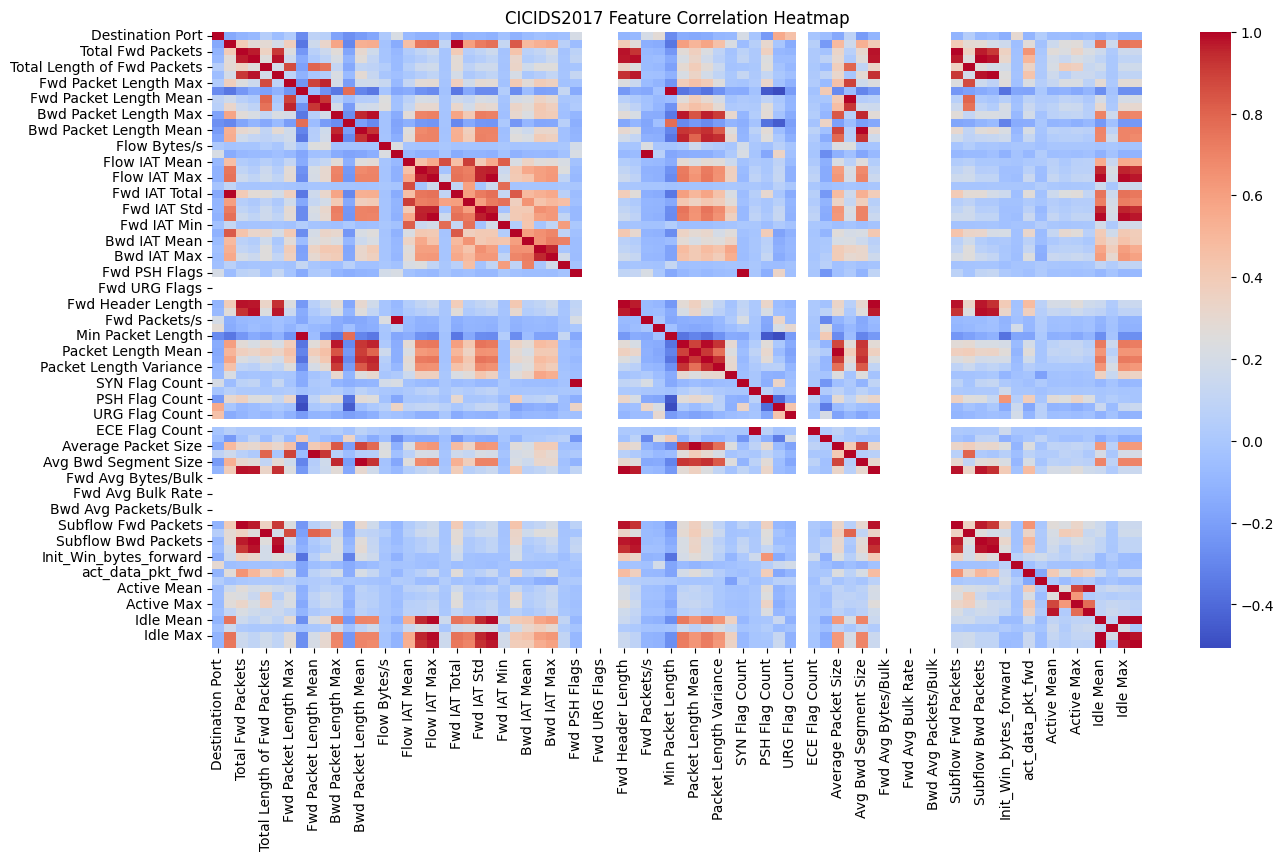


Top Features: Index(['Bwd Packet Length Std', 'Fwd IAT Std', 'Packet Length Variance',
       'Bwd Packet Length Max', 'Fwd IAT Max', 'Flow IAT Max',
       'Packet Length Std', 'Idle Mean'],
      dtype='object')


In [ ]:
print("===== MULTI CLASS QML IDS =====")


print("\n===== CORRELATION MATRIX =====")

# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Compute correlation
corr_matrix = numeric_data.corr()

# Show first few rows (optional)
print(corr_matrix.head())

# ------------------------------------------------
# HEATMAP
# ------------------------------------------------

numeric_data = data.select_dtypes(include=[np.number])

corr_matrix = numeric_data.corr()

plt.figure(figsize=(15,8))

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("CICIDS2017 Feature Correlation Heatmap")

plt.show()

# ------------------------------------------------
# FEATURE SELECTION
# ------------------------------------------------

temp = data.copy()

encoder = LabelEncoder()

temp["Label"] = encoder.fit_transform(temp["Label"])

corr_matrix = temp.corr()

label_corr = corr_matrix["Label"].abs().sort_values(ascending=False)

top_features = label_corr.index[1:9]

print("\nTop Features:", top_features)

# ------------------------------------------------
# PREPARE DATA
# ------------------------------------------------

X = data[top_features]

y = data["Label"]

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# ------------------------------------------------
# KEEP TOP 3 CLASSES (Improves Accuracy)
# ------------------------------------------------

class_counts = pd.Series(y_encoded).value_counts()

top_classes = class_counts.nlargest(3).index

mask = np.isin(y_encoded, top_classes)

X = X[mask]

y_encoded = y_encoded[mask]

# ------------------------------------------------
# NORMALIZATION
# ------------------------------------------------

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------
# PCA (QUANTUM LIMIT)
# ------------------------------------------------

pca = PCA(n_components=4)

X_reduced = pca.fit_transform(X_scaled)

#Train Test

In [ ]:

# ------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X_reduced,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42

)

# ------------------------------------------------
# DATASET INFO
# ------------------------------------------------

print("\n===== DATASET SPLIT SUMMARY =====")

print("Total samples :", X_reduced.shape[0])
print("Training samples :", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Features after PCA :", X_train.shape[1])
print("Classes :", len(np.unique(y_train)))

# -----------------------------
# TRAIN MODELS + METRICS
# -----------------------------
def report(name, y_true, y_pred):
    print(f"\n===== {name} RESULTS =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

results = []


===== DATASET SPLIT SUMMARY =====
Total samples : 592
Training samples : 473
Testing samples : 119
Features after PCA : 4
Classes : 3


#ML

In [ ]:
# =================================================
# CLASSICAL MACHINE LEARNING MODELS
# =================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("\nTraining Logistic Regression")

t0 = time()
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_time = time() - t0
report("LOGISTIC REGRESSION", y_test, lr_pred)
results.append(("Logistic Regression", accuracy_score(y_test, lr_pred), lr_time))
#print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nTraining Random Forest")

t0 = time()
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_time = time() - t0
report("RANDOM FOREST", y_test, rf_pred)
results.append(("Random Forest", accuracy_score(y_test, rf_pred), rf_time))
#print("Accuracy:", accuracy_score(y_test, rf_pred))


from sklearn.neighbors import KNeighborsClassifier

print("\nTraining KNN")

t0 = time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_time = time() - t0

report("KNN", y_test, knn_pred)
results.append(("KNN", accuracy_score(y_test, knn_pred), knn_time))


from sklearn.tree import DecisionTreeClassifier

print("\nTraining Decision Tree")

t0 = time()
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_time = time() - t0

report("DECISION TREE", y_test, dt_pred)
results.append(("Decision Tree", accuracy_score(y_test, dt_pred), dt_time))


from sklearn.naive_bayes import GaussianNB

print("\nTraining Naive Bayes")

t0 = time()
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_time = time() - t0

report("NAIVE BAYES", y_test, nb_pred)
results.append(("Naive Bayes", accuracy_score(y_test, nb_pred), nb_time))


Training Logistic Regression

===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 0.9747899159663865

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       104
           3       0.93      0.93      0.93        14
           6       0.00      0.00      0.00         1

    accuracy                           0.97       119
   macro avg       0.64      0.64      0.64       119
weighted avg       0.97      0.97      0.97       119


Confusion Matrix:
[[103   1   0]
 [  1  13   0]
 [  1   0   0]]

Training Random Forest

===== RANDOM FOREST RESULTS =====
Accuracy: 0.9663865546218487

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       104
           3       0.81      0.93      0.87        14
           6       1.00      1.00      1.00         1

    accuracy                           0.97       119
   macro avg       0.93      0.97      0.95   

#QSVM

In [ ]:

# ------------------------------------------------
# QUANTUM FEATURE MAP
# ------------------------------------------------

feature_map = ZZFeatureMap(

    feature_dimension=4,
    reps=2,
    entanglement="full"

)

# ------------------------------------------------
# QSVM MODEL
# ------------------------------------------------

print("\nTraining QSVM")

kernel = FidelityQuantumKernel(feature_map=feature_map)
t0 = time()
qsvm = QSVC(quantum_kernel=kernel)
qsvm.fit(X_train, y_train)
qsvm_pred = qsvm.predict(X_test)
qsvm_time = time() - t0

report("QSVM", y_test, qsvm_pred)
results.append(("QSVM", accuracy_score(y_test, qsvm_pred), qsvm_time))

/tmp/ipykernel_5311/692573099.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(



Training QSVM

===== QSVM RESULTS =====
Accuracy: 0.9747899159663865

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       104
           3       1.00      0.86      0.92        14
           6       0.00      0.00      0.00         1

    accuracy                           0.97       119
   macro avg       0.66      0.62      0.64       119
weighted avg       0.97      0.97      0.97       119


Confusion Matrix:
[[104   0   0]
 [  2  12   0]
 [  1   0   0]]


#


#QNN

In [ ]:
# =================================================
# QUANTUM NEURAL NETWORK
# =================================================

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import RealAmplitudes
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_algorithms.optimizers import SPSA

print("\nTraining QNN")

ansatz = RealAmplitudes(num_qubits=4, reps=2)

qc = QuantumCircuit(4)

qc.compose(feature_map, inplace=True)

qc.compose(ansatz, inplace=True)

sampler = StatevectorSampler()

qnn = SamplerQNN(

    circuit=qc,
    sampler=sampler,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters

)

optimizer = SPSA(maxiter=100)
t0 = time()
qnn_classifier = NeuralNetworkClassifier(

    neural_network=qnn,
    optimizer=optimizer

)
qnn_classifier.fit(X_train, y_train)
qnn_pred = qnn_classifier.predict(X_test)
qnn_time = time() - t0
report("QNN", y_test, qnn_pred)
results.append(("QNN", accuracy_score(y_test, qnn_pred), qnn_time))
print("\nQNN RESULTS")
print("Accuracy:", accuracy_score(y_test, qnn_pred))


/tmp/ipykernel_5311/2160169174.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=4, reps=2)



Training QNN

===== QNN RESULTS =====
Accuracy: 0.1092436974789916

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.12      0.22       104
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0

    accuracy                           0.11       119
   macro avg       0.08      0.01      0.02       119
weighted avg       0.81      0.11      0.19       119


Confusion Matrix:
[[13  2 68  3  4  0  0 13  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0]
 [ 0

#ROC Curve


===== ROC CURVE COMPARISON =====


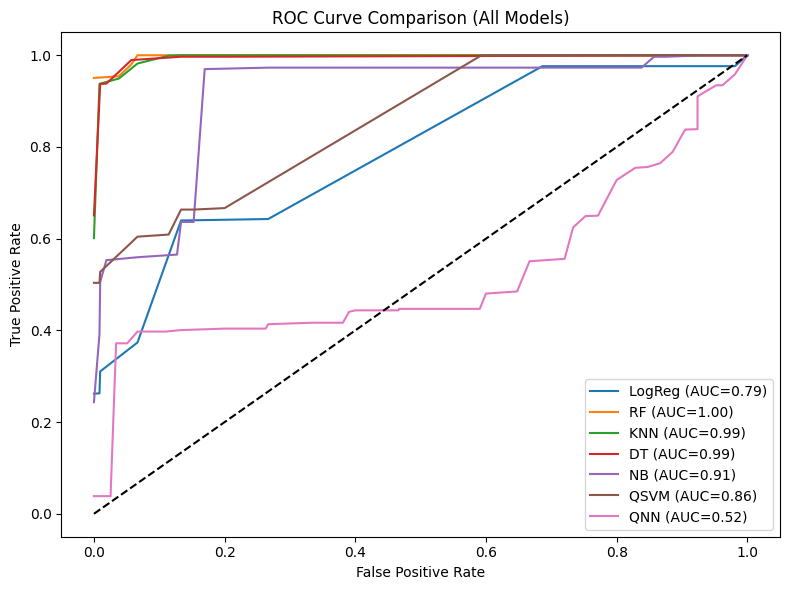


===== AUC VALUES =====
    Model       AUC
0  LogReg  0.787482
1      RF  0.997462
2     KNN  0.994927
3      DT  0.994048
4      NB  0.910118
5    QSVM  0.856927
6     QNN  0.523198


In [ ]:
# -----------------------------
# ROC CURVE + AUC (UPDATED)
# -----------------------------

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def get_scores_safe(model, X, model_name):
    try:
        # Case 1: Models with predict_proba
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)

        # Case 2: Models with decision_function (like SVM)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X)

            # Handle binary case
            if scores.ndim == 1:
                scores = np.vstack([-scores, scores]).T

            return scores

        else:
            print(f"{model_name} skipped (no probability output)")
            return None

    except Exception as e:
        print(f"{model_name} failed: {e}")
        return None


def plot_macro_roc(y_true, score_matrix, label):
    classes = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=classes)

    n_classes = y_bin.shape[1]

    fpr = {}
    tpr = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], score_matrix[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, label=f"{label} (AUC={macro_auc:.2f})")

    return macro_auc


print("\n===== ROC CURVE COMPARISON =====")

plt.figure(figsize=(8,6))

auc_results = []

# ✅ UPDATED MODEL LIST
model_dict = {
    "LogReg": lr,
    "RF": rf,
    "KNN": knn,
    "DT": dt,
    "NB": nb,
    "QSVM": qsvm,
    "QNN": qnn_classifier
}

for name, model in model_dict.items():
    scores = get_scores_safe(model, X_test, name)

    if scores is not None:
        try:
            auc_val = plot_macro_roc(y_test, scores, name)
            auc_results.append((name, auc_val))
        except Exception as e:
            print(f"{name} skipped (ROC error): {e}")

# Diagonal line
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# AUC TABLE
# -----------------------------
auc_df = pd.DataFrame(auc_results, columns=["Model", "AUC"])

print("\n===== AUC VALUES =====")
print(auc_df)

#Confusion Matrix


===== CONFUSION MATRICES =====


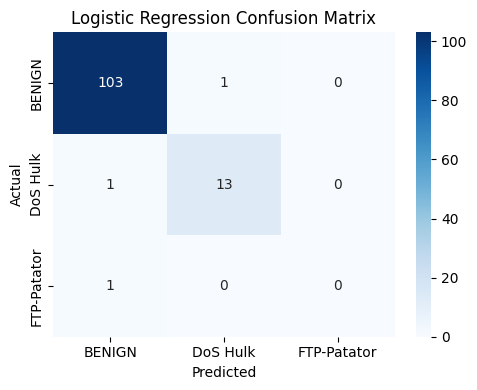

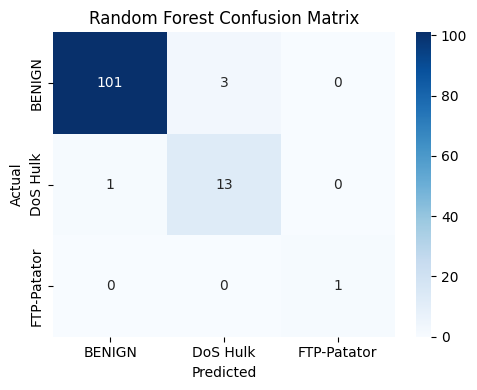

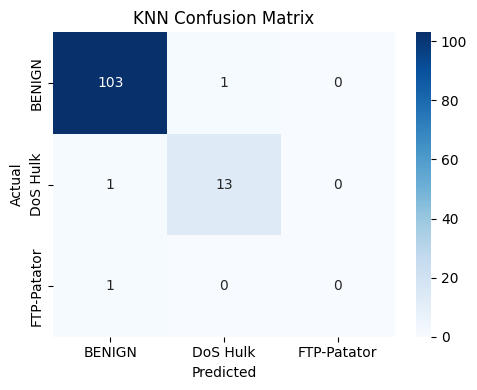

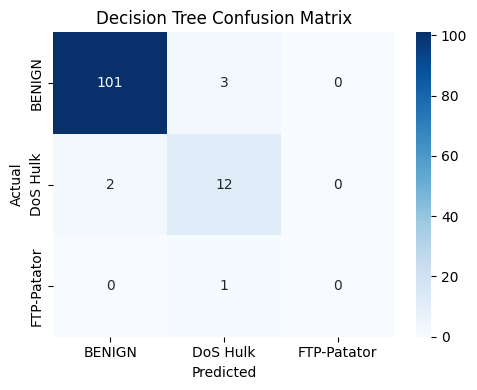

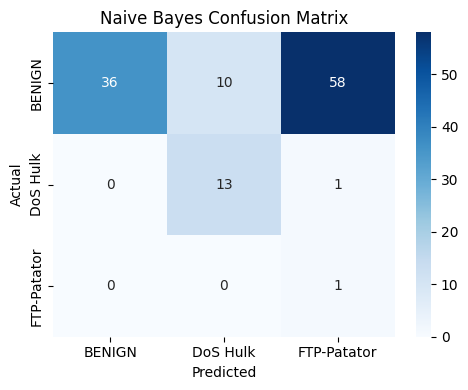

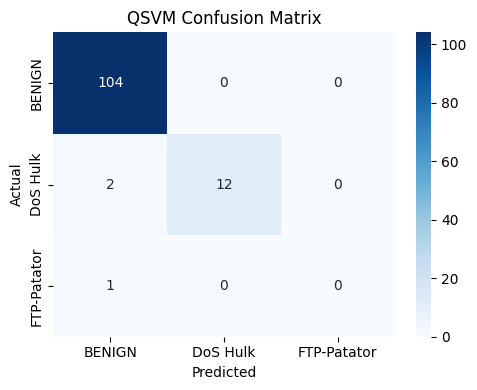

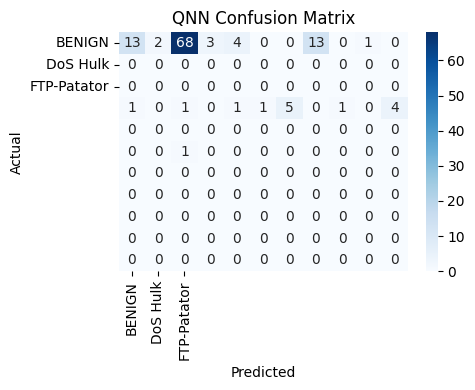

In [ ]:
# -----------------------------
# CONFUSION MATRIX HEATMAP (UPDATED)
# -----------------------------
from sklearn.metrics import confusion_matrix

def plot_conf_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


print("\n===== CONFUSION MATRICES =====")

# Get class names (important for readability)
class_names = label_encoder.inverse_transform(np.unique(y_test))

# Store all predictions in one place
predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Naive Bayes": nb_pred,
    "QSVM": qsvm_pred,
    "QNN": qnn_pred
}

# Plot all confusion matrices
for name, pred in predictions.items():
    plot_conf_matrix(y_test, pred, f"{name} Confusion Matrix", class_names)

#User Input

In [ ]:
# -----------------------------
# SINGLE INPUT PREDICTION (FIXED)
# -----------------------------
print("\n===== SINGLE INPUT PREDICTION =====")
print("Enter values for these features (same order):")

for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")

user_vals = []

for f in top_features:
    while True:
        try:
            val = float(input(f"Enter value for '{f}': "))
            user_vals.append(val)
            break
        except ValueError:
            print("Invalid input! Please enter a numeric value.")

# Convert input
user_X = np.array(user_vals).reshape(1, -1)

# Apply SAME preprocessing
user_scaled = scaler.transform(user_X)
user_reduced = pca.transform(user_scaled)

# -----------------------------
# MODEL DICTIONARY (FIXED)
# -----------------------------
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "KNN": knn,
    "Decision Tree": dt,
    "Naive Bayes": nb,
    "QSVM": qsvm,
    "QNN": qnn_classifier
}

print("\n===== PREDICTION RESULTS =====")

for name, model in models.items():
    try:
        pred = model.predict(user_reduced)[0]
        label = label_encoder.inverse_transform([pred])[0]

        # Confidence / score handling
        if hasattr(model, "predict_proba"):
            conf = np.max(model.predict_proba(user_reduced))
            print(f"{name:20}: {label} (Confidence: {conf:.2f})")

        elif hasattr(model, "decision_function"):
            score = model.decision_function(user_reduced)
            conf = np.max(score)
            print(f"{name:20}: {label} (Score: {conf:.2f})")

        else:
            # Quantum models fallback
            print(f"{name:20}: {label} (No confidence available)")

    except Exception as e:
        print(f"{name:20}: Error -> {e}")


===== SINGLE INPUT PREDICTION =====
Enter values for these features (same order):
1. Bwd Packet Length Std
2. Fwd IAT Std
3. Packet Length Variance
4. Bwd Packet Length Max
5. Fwd IAT Max
6. Flow IAT Max
7. Packet Length Std
8. Idle Mean
Enter value for 'Bwd Packet Length Std': 119.52
Enter value for 'Fwd IAT Std': 0
Enter value for 'Packet Length Variance': 11562
Enter value for 'Bwd Packet Length Max': 287
Enter value for 'Fwd IAT Max': 460
Enter value for 'Flow IAT Max': 381
Enter value for 'Packet Length Std': 107.52
Enter value for 'Idle Mean': 52


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



===== PREDICTION RESULTS =====
Logistic Regression : BENIGN (Confidence: 0.94)
Random Forest       : BENIGN (Confidence: 1.00)
KNN                 : BENIGN (Confidence: 1.00)
Decision Tree       : BENIGN (Confidence: 0.99)
Naive Bayes         : BENIGN (Confidence: 1.00)
QSVM                : BENIGN (Score: 2.22)
QNN                 : DoS GoldenEye (Confidence: 0.30)


In [ ]:
# -----------------------------
# SINGLE INPUT PREDICTION
# -----------------------------
print("\n===== SINGLE INPUT PREDICTION =====")
print("Enter values for these features (same order):")

for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")

user_vals = []

for f in top_features:
    while True:
        try:
            val = float(input(f"Enter value for '{f}': "))
            user_vals.append(val)
            break
        except:
            print("Invalid input! Please enter a numeric value.")

# Convert input
user_X = np.array(user_vals).reshape(1, -1)

# Apply SAME preprocessing
user_scaled = scaler.transform(user_X)
user_reduced = pca.transform(user_scaled)

# Predictions
pred_lr = lr.predict(user_reduced)[0]
pred_rf = rf.predict(user_reduced)[0]
pred_qsvm = qsvm.predict(user_reduced)[0]
pred_qnn = qnn_classifier.predict(user_reduced)[0]

# Confidence (important for project)
lr_conf = max(lr.predict_proba(user_reduced)[0])
rf_conf = max(rf.predict_proba(user_reduced)[0])

# Print results
print("\n===== PREDICTION RESULTS =====")

print(f"Logistic Regression: {label_encoder.inverse_transform([pred_lr])[0]} (Confidence: {lr_conf:.2f})")
print(f"Random Forest      : {label_encoder.inverse_transform([pred_rf])[0]} (Confidence: {rf_conf:.2f})")
print(f"QSVM               : {label_encoder.inverse_transform([pred_qsvm])[0]}")
print(f"QNN                : {label_encoder.inverse_transform([pred_qnn])[0]}")


===== SINGLE INPUT PREDICTION =====
Enter values for these features (same order):
1. Bwd Packet Length Std
2. Fwd IAT Std
3. Packet Length Variance
4. Bwd Packet Length Max
5. Fwd IAT Max
6. Flow IAT Max
7. Packet Length Std
8. Idle Mean
Enter value for 'Bwd Packet Length Std': 119.521
Enter value for 'Fwd IAT Std': 
Invalid input! Please enter a numeric value.
Enter value for 'Fwd IAT Std': 0
Enter value for 'Packet Length Variance': n/a
Invalid input! Please enter a numeric value.
Enter value for 'Packet Length Variance': 11562
Enter value for 'Bwd Packet Length Max': 287
Enter value for 'Fwd IAT Max': 460
Enter value for 'Flow IAT Max': 381
Enter value for 'Packet Length Std': 107.52
Enter value for 'Idle Mean': 52


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



===== PREDICTION RESULTS =====
Logistic Regression: BENIGN (Confidence: 0.94)
Random Forest      : BENIGN (Confidence: 1.00)
QSVM               : BENIGN
QNN                : DoS Hulk


In [ ]:
import numpy as np
import random

# Select unique attack labels
attack_types = np.unique(y_test)

for attack in attack_types:
    # Get indices of that attack type
    indices = np.where(y_test == attack)[0]

    # Pick a random sample
    sample_idx = random.choice(indices)

    # Get input and true label
    sample_input = X_test[sample_idx].reshape(1, -1)
    true_label = attack

    # ---- Choose model (uncomment what you use) ----

    # Classical ML (Random Forest / Logistic Regression)
    pred = model.predict(sample_input)[0]

    # QSVM
    print('QSVM')
    pred = qsvm.predict(sample_input)[0]

    # QNN
    # pred = qnn_classifier.predict(sample_input)[0]

    print(f"Actual: {true_label}")
    print(f"Predicted: {pred}")
    print("-" * 40)



QSVM
Actual: 0
Predicted: 0
----------------------------------------
QSVM
Actual: 3
Predicted: 3
----------------------------------------
QSVM
Actual: 6
Predicted: 0
----------------------------------------
